In [11]:
import glob
import re 
import os 
import itertools
import json
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [12]:
with open('../data/rifle_colorado_sediment_reads_paths.json', 'r') as f:
    reads_paths = json.load(f)
print(f'Num. biotite directories potentially containing Rifle data: {len(reads_paths)}')

exclude_patterns = ['RES.*|REG.*'] # These are the rice paddy samples. 
exclude_patterns += ['Petaluma.*']
exclude_patterns += ['FFPP.*']
exclude_patterns += ['FFSP.*']
exclude_patterns += ['ALT.*']
exclude_patterns += ['FFC.*']
exclude_patterns += ['OR.*']
exclude_patterns += ['ERM.*']
exclude_patterns += ['DGJ.*']
exclude_patterns += ['GOSHIP.*']
exclude_patterns += ['DWD.*']
exclude_patterns += ['BAPIC.*']
exclude_patterns += ['NEC.*']
exclude_patterns += ['NANO.*']
exclude_patterns += [r'L\d.*']
exclude_patterns += ['CG.*']
exclude_patterns += ['ARSTAG.*']
exclude_patterns += ['2013_.*']
exclude_patterns += ['Sorghum.*']
exclude_patterns += ['SR-VP.*']
exclude_patterns += ['Sac.*']
exclude_patterns += ['Cattle.*']
exclude_patterns += ['08E.*']
exclude_patterns += ['Australia.*']
exclude_patterns += ['12C.*']
exclude_patterns += ['SPOT.*']
exclude_patterns += ['EastRiver.*']
exclude_patterns += ['.*SCN.*']
exclude_patterns += ['Sage.*']
exclude_patterns += ['SJ.*']
exclude_patterns += ['BML.*']
exclude_patterns += ['^1(4|3).*']
exclude_patterns += [r'13_\d_\d0CM_*'] # I checked ggKbase, these are from the 2013 Angelo Meadows soil project.
exclude_pattern = '|'.join(exclude_patterns)

dir_paths = list(reads_paths.keys())
for dir_path in dir_paths:
    if re.match(exclude_pattern, os.path.basename(dir_path), flags=re.DOTALL):
        del reads_paths[dir_path]

# Theoretically, there should be 24 sets of reads from Rifle, as per Table 1 from https://pmc.ncbi.nlm.nih.gov/articles/PMC4511941/pdf/ismej20152a.pdf. 
print(f'Num. biotite directories remaining: {len(reads_paths)}')
# print('\n'.join(list(reads_paths.keys())))

print(f'Num. unique reads files: {len(np.unique(np.ravel(list(reads_paths.values())))) / 2}')
# print(reads_paths)

Num. biotite directories potentially containing Rifle data: 424
Num. biotite directories remaining: 21
Num. unique reads files: 14.0


In [13]:
def parse_project_id(project_id):
    '''Extract depth, replicate number, and sampling year (CSP) from the project ID.'''
    info = {'project_id':project_id}
    info['depth'] = re.search('10|13|19|16', project_id).group(0)
    project_id = project_id.replace(info['depth'], '') # Avoid the rep or CSP pattern matching the depth.
    info['csp'] = re.search(r'(csp|CSP)(\d)', project_id).group(2) if (re.search(r'(csp|CSP)(\d)', project_id) is not None) else None
    info['replicate'] = re.search(r'_(\d)', project_id).group(1)
    return info

sample_metadata_df = list()
for dir_path, reads_paths_ in reads_paths.items():
    row = dict()
    row['forward_reads_path'] = os.path.join(dir_path, 'raw.d', sorted(reads_paths_)[0])
    row['reverse_reads_path'] = os.path.join(dir_path, 'raw.d', sorted(reads_paths_)[1])
    row['year'] = re.search(r'(20\d\d)', dir_path).group(1)
    dir_name = os.path.basename(dir_path) # Make sure the depth pattern doesn't match the year.
    row['dir_name'] = dir_name 
    row.update(parse_project_id(dir_name))
    sample_metadata_df.append(row)
    
sample_metadata_df = pd.DataFrame(sample_metadata_df)
sample_metadata_df['replicate'] = sample_metadata_df.replicate.astype(int)
sample_metadata_df['depth'] = sample_metadata_df.depth.astype(float)
sample_metadata_df['csp'] = sample_metadata_df.depth.astype(float)
sample_metadata_df.to_csv('../data/rifle_colorado_sediment_sample_metadata.csv')



In [14]:
# Info from Table 1 of the source paper. 

table_1_df = list()
table_1_df.append({'csp':1, 'replicate':1, 'depth':10, 'library_size_gigabases':42.4, 'libary_size_num_reads':282})
table_1_df.append({'csp':1, 'replicate':2, 'depth':10, 'library_size_gigabases':47.1, 'libary_size_num_reads':314})

table_1_df.append({'csp':1, 'replicate':1, 'depth':13, 'library_size_gigabases':47.3, 'libary_size_num_reads':315})
table_1_df.append({'csp':1, 'replicate':2, 'depth':13, 'library_size_gigabases':16.3, 'libary_size_num_reads':108})
table_1_df.append({'csp':1, 'replicate':3, 'depth':13, 'library_size_gigabases':16.6, 'libary_size_num_reads':110})
table_1_df.append({'csp':1, 'replicate':4, 'depth':13, 'library_size_gigabases':41.5, 'libary_size_num_reads':276})

table_1_df.append({'csp':1, 'replicate':1, 'depth':16, 'library_size_gigabases':48.2, 'libary_size_num_reads':322})
table_1_df.append({'csp':1, 'replicate':2, 'depth':16, 'library_size_gigabases':48.2, 'libary_size_num_reads':321})
table_1_df.append({'csp':1, 'replicate':3, 'depth':16, 'library_size_gigabases':43.9, 'libary_size_num_reads':293})
table_1_df.append({'csp':1, 'replicate':4, 'depth':16, 'library_size_gigabases':37.9, 'libary_size_num_reads':253})

table_1_df.append({'csp':1, 'replicate':1, 'depth':19, 'library_size_gigabases':30.3, 'libary_size_num_reads':202})
table_1_df.append({'csp':1, 'replicate':2, 'depth':19, 'library_size_gigabases':46.1, 'libary_size_num_reads':308})
table_1_df.append({'csp':1, 'replicate':3, 'depth':19, 'library_size_gigabases':43.8, 'libary_size_num_reads':292})
table_1_df.append({'csp':1, 'replicate':4, 'depth':19, 'library_size_gigabases':41.7, 'libary_size_num_reads':278})

table_1_df.append({'csp':2, 'replicate':1, 'depth':10, 'library_size_gigabases':51.3, 'libary_size_num_reads':342})
table_1_df.append({'csp':2, 'replicate':2, 'depth':10, 'library_size_gigabases':54.7, 'libary_size_num_reads':364})
table_1_df.append({'csp':2, 'replicate':3, 'depth':10, 'library_size_gigabases':53, 'libary_size_num_reads':353})

table_1_df.append({'csp':2, 'replicate':1, 'depth':13, 'library_size_gigabases':47.8, 'libary_size_num_reads':319})
table_1_df.append({'csp':2, 'replicate':2, 'depth':13, 'library_size_gigabases':48.5, 'libary_size_num_reads':323})

table_1_df.append({'csp':2, 'replicate':2, 'depth':16, 'library_size_gigabases':51.2, 'libary_size_num_reads':342})
table_1_df.append({'csp':2, 'replicate':3, 'depth':16, 'library_size_gigabases':46.6, 'libary_size_num_reads':311})

table_1_df.append({'csp':2, 'replicate':1, 'depth':19, 'library_size_gigabases':23.4, 'libary_size_num_reads':156})
table_1_df.append({'csp':2, 'replicate':2, 'depth':19, 'library_size_gigabases':37.6, 'libary_size_num_reads':251})
table_1_df.append({'csp':2, 'replicate':3, 'depth':19, 'library_size_gigabases':44.4, 'libary_size_num_reads':296})

table_1_df = pd.DataFrame(table_1_df)
table_1_sample_ids = [f'csp{row.csp}_{row.depth}ft_{row.replicate}' for row in table_1_df.itertuples()]

table_1_df = table_1_df.pivot(index=['replicate', 'depth'], columns='csp', values='library_size_gigabases').reset_index()
table_1_df = table_1_df.rename(columns={1:'csp_1_library_size', 2:'csp_2_library_size'})

# In general, the number of reads bbduk reports to be in the library is about 4-5e6 fewer than reported in Table 1.
# This is based on comparison of read counts from CSP 1 10ft samples. I imagine this is the result of filtering.



In [15]:
def bbduk_load(data_dir='../data/bbduk'):
    bbduk_df = list()
    for path in glob.glob(os.path.join(data_dir, '*')):
        with open(path, 'r') as f:
            content = f.read()
        row = dict()
        row['sample_id'] = os.path.basename(path).replace('.txt', '')
        row['library_size'] = int(re.search(r'#Total\s+(\d+)', content, flags=re.MULTILINE).group(1))
        bbduk_df.append(row)
    bbduk_df = pd.DataFrame(bbduk_df)
    return bbduk_df.set_index('sample_id')

bbduk_df = bbduk_load()

In [16]:
sample_metadata_df['library_size'] = sample_metadata_df.dir_name.map(bbduk_df.library_size)
sample_metadata_df['library_size'] = sample_metadata_df.library_size * 150 / 1e9 # Convert to gigabases, assuming read length of 150.
if 'csp_1_library_size' not in sample_metadata_df.columns:
    sample_metadata_df = sample_metadata_df.merge(table_1_df, on=['depth', 'replicate'])

Text(0, 0.5, 'library size (Gb)')

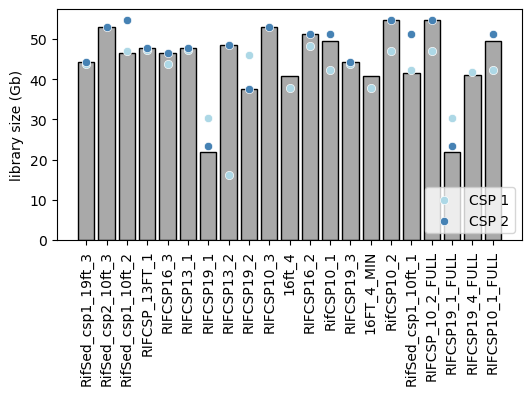

In [17]:
fig, ax = plt.subplots(figsize=(6, 3))
figure_df = sample_metadata_df.copy()

sns.barplot(figure_df, x='dir_name', y='library_size', color='darkgray', edgecolor='black')
sns.scatterplot(figure_df, x='dir_name', y='csp_1_library_size', color='lightblue', label='CSP 1')
sns.scatterplot(figure_df, x='dir_name', y='csp_2_library_size', color='steelblue', label='CSP 2')

ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), rotation=90)
ax.set_xlabel('')
ax.legend(loc='lower right')
ax.set_ylabel('library size (Gb)')

In [22]:
csp_map = dict()
csp_map['RifSed_csp1_19ft_3'] = 1
csp_map['RifSed_csp2_10ft_3'] = 2
csp_map['RifSed_csp1_10ft_2'] = 1
csp_map['RIFCSP_13FT_1'] = 2 #None #2 # Ambiguous.
csp_map['RIFCSP16_3'] = 2
csp_map['RIFCSP13_1'] = 2 # Ambiguous.
csp_map['RIFCSP19_1'] = 2
csp_map['RIFCSP13_2'] = 2
csp_map['RIFCSP19_2'] = 2
csp_map['RIFCSP10_3'] = 2
csp_map['16ft_4'] = 1
csp_map['RIFCSP16_2'] = 2 #None #2 # Ambiguous.
csp_map['RifCSP10_1'] = 2
csp_map['RIFCSP19_3'] = 2 #None # 2 # Ambiguous.
csp_map['16FT_4_MIN'] = 1
csp_map['RifCSP10_2'] = 2
csp_map['RifSed_csp1_10ft_1'] = 1 
csp_map['RIFCSP_10_2_FULL'] = 2
csp_map['RIFCSP19_1_FULL'] = 2
csp_map['RIFCSP19_4_FULL'] = 1
csp_map['RIFCSP10_1_FULL'] = 2

sample_metadata_df['csp'] = sample_metadata_df.dir_name.map(csp_map)
sample_metadata_df = sample_metadata_df.drop_duplicates(['csp', 'depth', 'replicate'])
biotite_sample_ids = [f'csp{int(row.csp)}_{int(row.depth)}ft_{int(row.replicate)}' for row in sample_metadata_df.itertuples()]

missing_sample_ids = [sample_id for sample_id in table_1_sample_ids if (sample_id not in biotite_sample_ids)]
print('Num. samples:', len(table_1_sample_ids))
print('Num. missing samples:', len(missing_sample_ids))
print()
print('\n'.join(missing_sample_ids))

Num. samples: 24
Num. missing samples: 9

csp1_13ft_1
csp1_13ft_2
csp1_13ft_3
csp1_13ft_4
csp1_16ft_1
csp1_16ft_2
csp1_16ft_3
csp1_19ft_1
csp1_19ft_2


In [ ]:
contigs_df = pd.read_csv('../data/rifle_colorado_sediment_seed_contigs.csv').drop(columns=['Unnamed: 8', 'depth'])
contigs_df = contigs_df.merge(pd.DataFrame([parse_project_id(project_id) for project_id in contigs_df.project_id.unique()]), on='project_id', how='left')
contigs_df['depth'] = contigs_df.depth.astype(float)
contigs_df['replicate'] = contigs_df.replicate.astype(float)
contigs_df['csp'] = contigs_df.csp.astype(float)

csp_map.update(contigs_df[~contigs_df.csp.isnull()].set_index('project_id').csp.to_dict())
# Not sure about these. 
csp_map['19ft_2_thinned'] = 2 # Project not specified in ggKbase, but this is best guess. 
csp_map['19FT_2_THINNED'] = 2 
contigs_df['csp'] = contigs_df.project_id.map(csp_map)

cols = ['depth', 'csp', 'replicate']
contigs_df = contigs_df.merge(sample_metadata_df[['forward_reads_path', 'reverse_reads_path', 'library_size'] + cols], on=cols, how='left')
contigs_df.set_index('contig_id').to_csv('../data/rifle_colorado_sediment_seed_contigs_with_metadata.csv')

In [ ]:
# prefetch SRR3972132 --max_size [max size in kB]
# fasterq-dump SRR3972132.sra --split-files -e 16 -O .
# mv SRR3972132.sra_1.fastq SRR3972132_1.fastq
# mv SRR3972132.sra_2.fastq SRR3972132_2.fastq

# -f is forward reads input. 
# -r is reverse reads input. 
# -t is quality score type. 
# -o is output for trimmed forward reads. 
# -p is output for trimmed reverse reads. 
# -s is for reads with no mate.

# sickle pe -f SRR3972132_1.fastq -r SRR3972132_2.fastq -t sanger -o SRR3972132_1.trimmed.fastq -p SRR3972132_2.trimmed.fastq -s SRR3972132_singles.fastq -q 20 -l 50
# pigz -p 16 SRR3972132_1.trimmed.fastq
# pigz -p 16  SRR3972132_2.trimmed.fastq

# SRAs for missing samples. 
sras = dict()
# Stored in /groups/banfield/projects/environmental/sr/int/philippar/SRR3972132

forward_reads_path = '/groups/banfield/scratch/projects/environmental/sr/int/philippar/SRR3972132/SRR3972132_1.trimmed.fastq.gz'
reverse_reads_path = '/groups/banfield/scratch/projects/environmental/sr/int/philippar/SRR3972132/SRR3972132_2.trimmed.fastq.gz'

sras['csp_1_19ft_2'] = ('SRR3972132', 'https://www.ncbi.nlm.nih.gov/sra?linkname=bioproject_sra_all&from_uid=330110')



In [ ]:
# project_id_map = dict() 
# project_id_map['19ft_2_thinned'] = 'RIFCSP19_2'
# project_id_map['19FT_2_THINNED'] = 'RIFCSP19_2'
# project_id_map['RifSed_csp1_19ft_4'] = 'RIFCSP19_4_FULL'
# project_id_map['RifSed_csp2_19ft_3'] = 'RIFCSP19_3'
# project_id_map['RifSed_csp1_10ft_1_unmapped'] = 'RifSed_csp1_10ft_1'
# project_id_map['RifSed_csp2_10ft_1'] = 'RIFCSP10_1_FULL'
# project_id_map['RifSed_csp2_19ft_2'] = 'RIFCSP19_2'
# project_id_map['RifSed_csp2_16ft_3'] = 'RIFCSP16_3'
# contigs_df['project_id'] = contigs_df.project_id.replace(project_id_map)


In [ ]:
# # RIFCSP19_2 library size best matches CSP 2
# # RIFCSP19_1 library size best matches CSP 2
# # RIFCSP19_1 library size best matches CSP 2. Maps to the same file as RIFCSP19_1_FULL
# # RIFCSP19_3 library size best matches CSP 2. Maps to the same file as RifSed_csp1_19ft_3. Was this mislabeled?
# # RIFCSP19_4_FULL library size best matches CSP 1; also, there is no replicate 4 with CSP 2.
# # RifSed_csp1_10ft_2 is definitely CSP 1.
# # RIFCSP_10_2_FULL and RIFCSP10_2 both map to the same file, and sizes best match CSP 2.
# # 16ft_4 and 16FT_4_MIN both map to the same file, with library size best matching CSP 1; also there is no replicate 4 in CSP 1.
# # RIFCSP_13FT_3 best matches CSP 2; also, there is no replicate 3 at that depth in CSP 1.
# # RIFCSP16_2 best matches CSP 2
# # RifCSP10_1 and RifCSP10_1_FULL both map to the same file, with library size best matching CSP 2.
# # RifSed_csp2_10ft_3 is definitely CSP 2.
# # RIFCSP13_2 library size matches CSP 2
# # RIFCSP13_1 is sort of ambiguous, but probably CSP 2.

# csp_map = dict()
# csp_map['RIFCSP19_2'] = 2
# csp_map['RIFCSP19_3'] = 2
# csp_map['RIFCSP19_1'] = 2
# csp_map['RIFCSP19_1_FULL'] = 2
# csp_map['RifSed_csp1_19ft_3'] = 2 # Mislabeled?
# csp_map['RIFCSP19_4_FULL'] = 1
# csp_map['RifSed_csp1_10ft_2'] = 1
# csp_map['RIFCSP_10_2_FULL'] = 2
# csp_map['RIFCSP_10_2'] = 2
# csp_map['RIFCSP_10_1'] = 2
# csp_map['RIFCSP_10_1_FULL'] = 2
# csp_map['RIFCSP_13FT_3'] = 2
# csp_map['RIFCSP13_2'] = 2
# csp_map['RIFCSP13_1'] = 2
# csp_map['RIFCSP16_2'] = 2
# csp_map['16ft_4'] = 1
# csp_map['16FT_4_MIN'] = 1
# csp_map['RIFCSP16_2'] = 2